In [1]:
!pip install jcopdl==1.1.10

  Preparing metadata (setup.py) ... done
  Created wheel for jcopdl: filename=jcopdl-1.1.10-py2.py3-none-any.whl size=17915 sha256=413afea54a1a8868691ea40e88517191b05bf7fa0acb233c003a0aa4f6fd1e9c
  Stored in directory: /root/.cache/pip/wheels/0b/f2/20/aac0878bab38dc24137a63e0977201d72a5f892039d6b38885
Successfully built jcopdl


Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
from torch import nn, optim
from jcopdl.callback import Callback, set_config

from jcopdl.utils.dataloader import TimeSeriesDataset
from torch.utils.data import DataLoader
import os

from tqdm.auto import tqdm
from sklearn.preprocessing import MinMaxScaler

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda:0


### Load Dataset

In [4]:
df = pd.read_csv("yahoo_stock.csv")
df.head()

,Date,High,Low,Open,Close,Volume,Adj Close
0,2015-11-23,2095.610107,2081.389893,2089.409912,2086.590088,3.587980e+09,2086.590088
1,2015-11-24,2094.120117,2070.290039,2084.419922,2089.139893,3.884930e+09,2089.139893
2,2015-11-25,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
3,2015-11-26,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
4,2015-11-27,2093.290039,2084.129883,2088.820068,2090.110107,1.466840e+09,2090.110107


/tmp/ipykernel_839/4270315760.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_close = df[['Close']].asfreq('D').fillna(method='ffill')


Shape: (1825, 1)


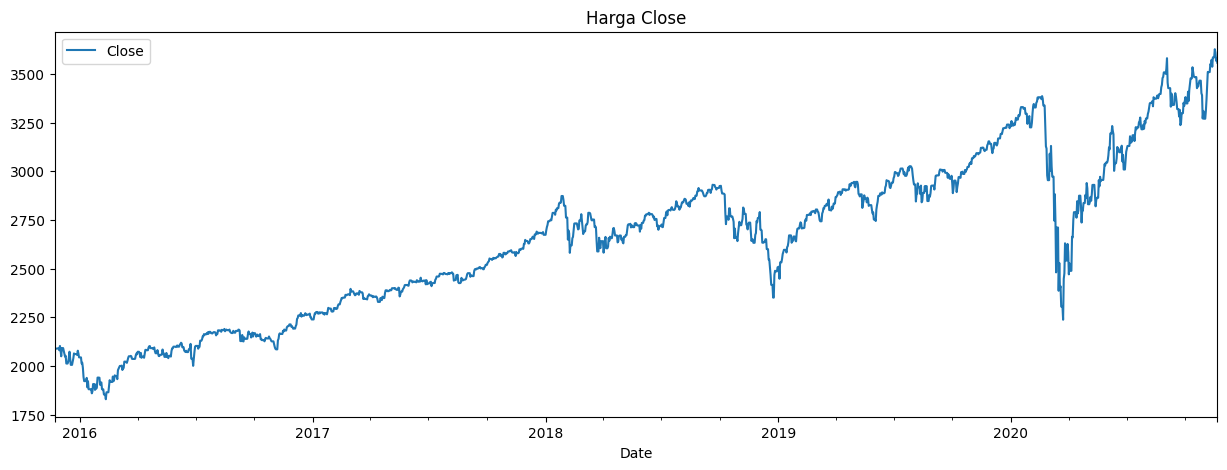

In [5]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# ambil kolom close, isi hari libur dengan forward fill
df_close = df[['Close']].asfreq('D').fillna(method='ffill')

print("Shape:", df_close.shape)
df_close.plot(figsize=(15, 5), title= "Harga Close")
plt.show()

Train test Split

In [6]:
ts_train, ts_test = train_test_split(df_close, test_size=0.2, shuffle=False)
print("Train:", ts_train.shape, "| Test:", ts_test.shape)

Train: (1460, 1) | Test: (365, 1)


Normalisasi

In [7]:
scaler = MinMaxScaler()

ts_train[['Close']] = scaler.fit_transform(ts_train[['Close']])
ts_test[['Close']] = scaler.transform(ts_test[['Close']])

Dataset & DataLoader

In [8]:
seq_len = 14 #14 Hari
bs = 32

train_set = TimeSeriesDataset(ts_train, "Close", seq_len)
trainloader = DataLoader(train_set, batch_size=bs, shuffle=False)

test_set = TimeSeriesDataset(ts_test, "Close", seq_len)
testloader = DataLoader(test_set, batch_size=bs, shuffle=False)

print("Fitur:", train_set.n_feature, "| Seq len:", train_set.n_seq)

(N, S, F): (104, 14, 1)
Note: last 3 data excluded

(N, S, F): (26, 14, 1)
Note: last 0 data excluded

Fitur: 1 | Seq len: 14


Model SLTM

In [9]:
class LSTM(nn.Module):
  def __init__(self, input_size, output_size, hidden_size, num_layers, dropout):
    super().__init__()
    self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
    self.fc = nn.Linear(hidden_size, output_size)

  def forward(self, x, hidden):
    x, hidden = self.lstm(x, hidden)
    x = self.fc(x)
    return x, hidden

Config dan Inisialisasi

In [10]:
os.makedirs("model/lstm", exist_ok=True)
config = set_config({
    "input_size": train_set.n_feature,
    "seq_len": train_set.n_seq,
    "output_size": 1,
    "hidden_size": 64,
    "num_layers": 2,
    "dropout": 0.2,
})

model = LSTM(config.input_size, config.output_size,
             config.hidden_size, config.num_layers, config.dropout).to(device)


criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3)
callback = Callback(model, config, outdir="model/lstm")

Training Loop

In [11]:
def loop_fn(mode, dataset, dataloader, model, criterion, optimizer, device):
    model.train() if mode == "train" else model.eval()

    cost = 0
    for feature, target in tqdm(dataloader, desc=mode.title()):
        feature, target = feature.to(device), target.to(device)
        output, hidden = model(feature, None)
        loss = criterion(output, target)

        if mode == "train":
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        cost += loss.item() * feature.shape[0]

    return cost / len(dataset)

Train:   0%|          | 0/4 [00:00<?, ?it/s]

Test:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch     1
Train_cost  = 0.3319 | Test_cost  = 0.9797 | 


Train:   0%|          | 0/4 [00:00<?, ?it/s]

Test:   0%|          | 0/1 [00:00<?, ?it/s]

...

Test:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch    19
Train_cost  = 0.0482 | Test_cost  = 0.1344 | 


Train:   0%|          | 0/4 [00:00<?, ?it/s]

Test:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch    20
Train_cost  = 0.0457 | Test_cost  = 0.1270 | 


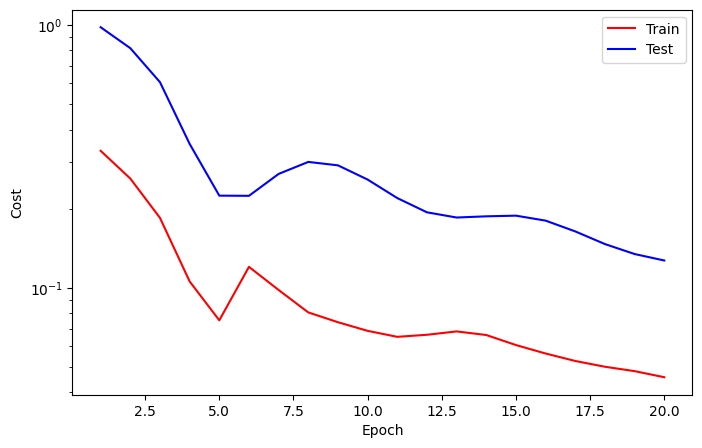

Train:   0%|          | 0/4 [00:00<?, ?it/s]

Test:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch    21
Train_cost  = 0.0417 | Test_cost  = 0.1208 | 


Train:   0%|          | 0/4 [00:00<?, ?it/s]

Test:   0%|          | 0/1 [00:00<?, ?it/s]

...

Test:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch    26
Train_cost  = 0.0273 | Test_cost  = 0.1535 | 
==> EarlyStop patience =  4 | Best test_cost: 0.1151


Train:   0%|          | 0/4 [00:00<?, ?it/s]

Test:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch    27
Train_cost  = 0.0270 | Test_cost  = 0.1624 | 
==> EarlyStop patience =  5 | Best test_cost: 0.1151
==> Execute Early Stopping at epoch: 27 | Best test_cost: 0.1151
==> Best model is saved at model/lstm


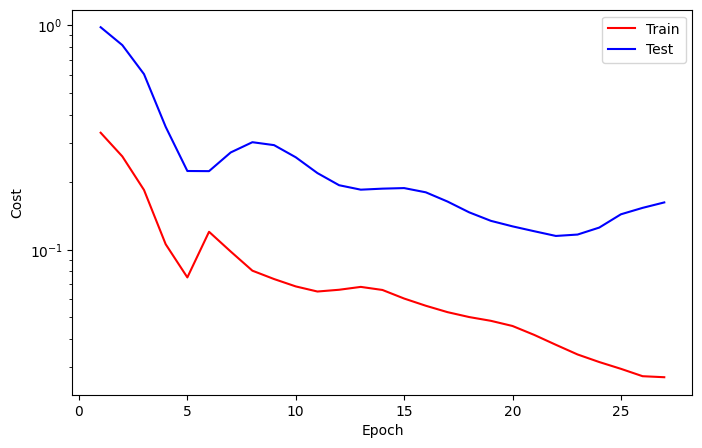

In [12]:
# Training dengan Early Stopping
while True:
    train_cost = loop_fn("train", train_set, trainloader, model, criterion, optimizer, device)
    with torch.no_grad():
        test_cost = loop_fn("test", test_set, testloader, model, criterion, optimizer, device)

    callback.log(train_cost, test_cost)
    callback.save_checkpoint()
    callback.cost_runtime_plotting()

    if callback.early_stopping(model, monitor="test_cost"):
        callback.plot_cost()
        break

Forecasting

In [13]:
train_fc_set = TimeSeriesDataset(ts_train, "Close", seq_len)
train_fc_loader = DataLoader(train_fc_set)
test_fc_set = TimeSeriesDataset(ts_test, "Close", seq_len)
test_fc_loader = DataLoader(test_fc_set)

def data4pred(model, dataset, dataloader, device):
  model.eval()
  all_preds, all_actuals = [], []

  with torch.no_grad():
    for feature, target in dataloader:
      feature = feature.to(device)
      # Reset hidden tiap batch, ambil semua timestep
      output, _ = model(feature, None)
      # Output shape: (batch, seq_len, 1)
      all_preds.extend(output[:, -1, 0].cpu().numpy())
      all_actuals.extend(target[:, -1, 0].numpy())

  plt.plot(all_actuals, label="Aktual")
  plt.plot(all_preds, label="Prediksi")
  plt.legend()

(N, S, F): (104, 14, 1)
Note: last 3 data excluded

(N, S, F): (26, 14, 1)
Note: last 0 data excluded



In [14]:
def pred4pred(model, dataset, dataloader, device, scaler, n_future=7):

    model.eval()

    all_preds = []
    all_actuals = []
    last_feature = None


    # Prediksi data test
    with torch.no_grad():
        for feature, target in dataloader:
            feature = feature.to(device)
            output, _ = model(feature, None)
            all_preds.extend(
                output[:, -1, 0].cpu().numpy()
            )
            all_actuals.extend(
                target[:, -1, 0].cpu().numpy()
            )
            last_feature = feature


    # Rolling Window Forecast

    # Ambil window terakhir
    window = last_feature[-1:, :, :].clone()
    future_preds = []

    with torch.no_grad():
        for _ in range(n_future):
            # Prediksi berdasarkan 14 hari terakhir
            output, _ = model(window, None)
            # Ambil prediksi terakhir
            next_val = output[:, -1:, :]
            future_preds.append(
                next_val.item()
            )
            # Geser window
            window = torch.cat(
                [
                    window[:, 1:, :],
                    next_val
                ],
                dim=1
            )

    # invers ke harga asli
    all_actuals_real = scaler.inverse_transform(
        np.array(all_actuals).reshape(-1, 1)
    ).flatten()

    all_preds_real = scaler.inverse_transform(
        np.array(all_preds).reshape(-1, 1)
    ).flatten()

    future_preds_real = scaler.inverse_transform(
        np.array(future_preds).reshape(-1, 1)
    ).flatten()


    # Visualisasi
    plt.figure(figsize=(15, 5))
    plt.plot(
        range(len(all_actuals_real)),
        all_actuals_real,
        label="Aktual"
    )
    plt.plot(
        range(len(all_preds_real)),
        all_preds_real,
        label="Prediksi (in-sample)"
    )
    plt.plot(
        range(
            len(all_actuals_real),
            len(all_actuals_real) + n_future
        ),
        future_preds_real,
        '--',
        label=f'Forecast {n_future} Hari'
    )
    plt.title(f'Forecast {n_future} Hari ke Depan (Harga Asli)')
    plt.legend()
    plt.grid(True)
    plt.show()

    return future_preds_real

Visualisasi

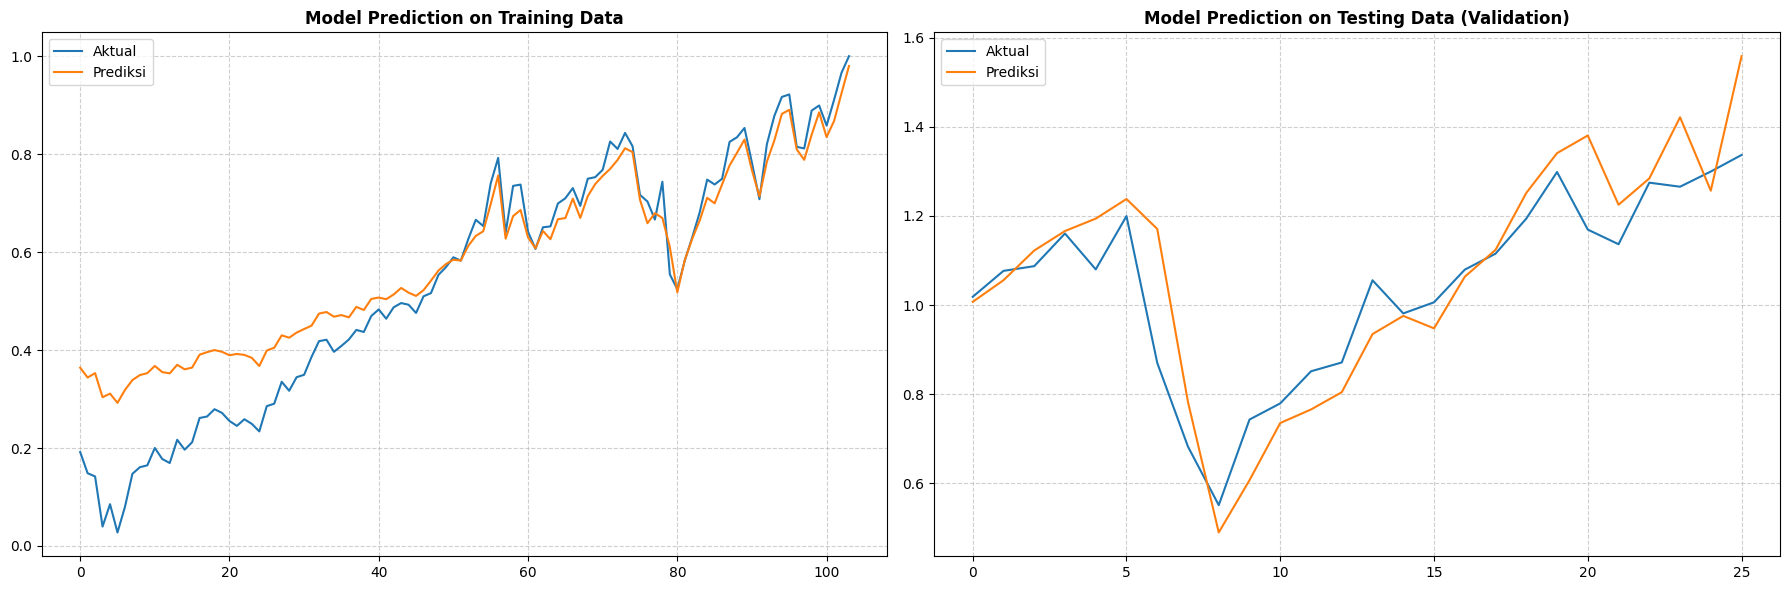

<Figure size 1200x500 with 0 Axes>

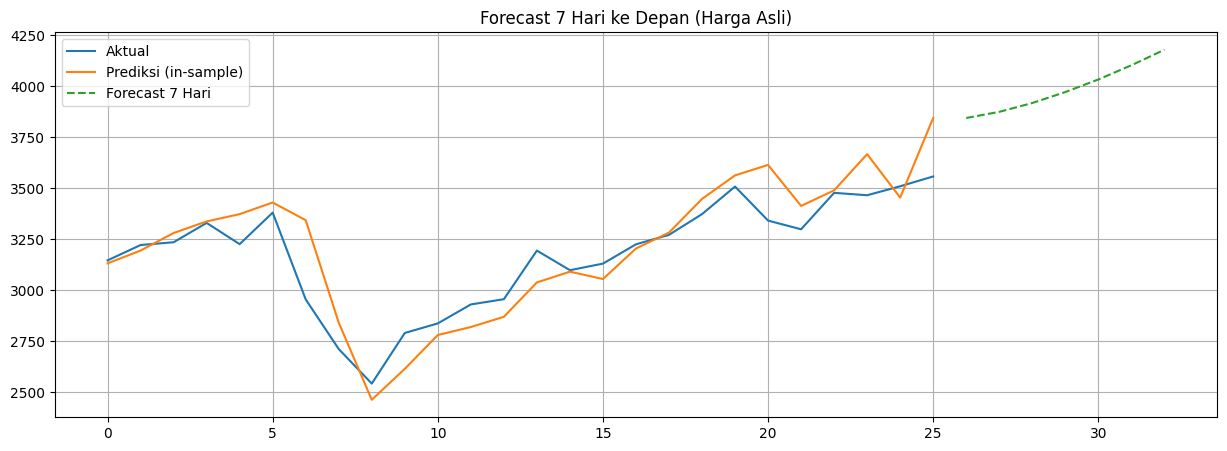

array([3844.23519078, 3874.35637037, 3917.70142983, 3971.51418683,
       4033.08130762, 4102.79459488, 4178.83236654])

In [19]:
# 1. GABUNGKAN TRAIN & TEST BERDAMPINGAN (1 Baris, 2 Kolom)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Visualisasi prediksi data train (Kiri)
plt.sca(axes[0]) # Set target plot ke kolom pertama
data4pred(model, train_fc_set, train_fc_loader, device)
plt.title("Model Prediction on Training Data", fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)

# Visualisasi prediksi data test (Kanan)
plt.sca(axes[1]) # Set target plot ke kolom kedua
data4pred(model, test_fc_set, test_fc_loader, device)
plt.title("Model Prediction on Testing Data (Validation)", fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Mengatur jarak otomatis agar label tidak bertumpukan
plt.show()

# ---

# 2. VISUALISASI FORECAST (Berdiri Sendiri Sebagai Penutup)
plt.figure(figsize=(12, 5))
pred4pred(
    model,
    test_fc_set,
    test_fc_loader,
    device,
    scaler,
    n_future=7
)